# Week 3: Memory — Rational Analysis, Catastrophic Forgetting, and Context

### Recap!

Over the past two weeks, we have explored several forms of <b> feedforward </b> neural networks:

- **Auto-encoders** trained to reconstruct their input through a small latent space (self-supervised)
- **Multi-layer perceptrons (MLPs)** trained to categorize inputs given labels (supervised)
- **Convolutional neural networks (CNNs)** — like AlexNet — that share features across spatial positions, producing brain-like hierarchical representations

All of these systems have a form of **memory**: they store information by adjusting their weights and biases through gradient descent. These parameter values — learned from experience — shape all future processing. *Carrying information forward in time by changing weights is itself a form of memory.*


> **Discussion Question 1:** In what ways is the "memory" stored in a network's weights similar to or different from the types of memory we discussed in lecture?
>
> - Is it more like **short-term** or **long-term** memory?
> - Is it **declarative** (facts you can articulate, "I know Paris is the capital of France") or **procedural/implicit** (knowing how to ride a bike)?
> - What about **episodic** memory — the memory of specific autobiographical events? Is there anything like that in a feedforward network?

Keep these questions in mind — we'll return to them throughout the lab and in coming weeks.


In today's lab we will cover three topics:


## Outline for Today
- **A.** <b> Rational analysis of memory </b> — why our networks' "spontaneous thoughts" reflect their experience
- **B.** <b> Catastrophic interference </b> — a fundamental failure of feedforward networks as memory systems
- **C.** <b> Recurrent neural networks </b> — a different type of neural network that can track context across time (think of short-term or working memory)

---



## A. Rational Analyses of Memory

What makes a memory system *good* or *bad*?

The **rational analysis** approach (Anderson, 1990; Chater & Oaksford, 1999) takes a functional perspective: instead of asking what mechanisms produce memory, it asks what memory *ought* to do. If we view memory as an optimization problem, what is it optimizing for?

**Anderson's answer:** memory is optimized for **need probability** — things you are *likely to need* again should be *easier to retrieve*. A good memory system doesn't just store everything equally; it prioritizes what's most likely to be useful.

### How do we estimate "need probability"?

A simple but sometimes powerful estimate is just **observed frequency**: <i> how often has something occurred in your experience? </i>. Some classic cognitive findings that support this idea:


### Real-World Examples of Need Probability

**1. The word frequency effect in memory.** You recognize "about" much faster than "abbot".  Why? You encounter "about" frequently — so the cost of making it quickly retrievable pays off. "abbot" appears roughly once per 2 million words of English. Your mental lexicon has learned this.


**2. The recency effect.** You remember the last few items on a list better than the middle ones — because recent events are statistically more likely to be relevant to your immediate next action.

**3. Dreaming and mind-wandering.** When your mind drifts, where does it go? Often to things you've been thinking about, worrying about, or encountering frequently. Your "spontaneous thoughts" seem to reflect the statistical distribution of your recent experience.


### Setting Up Our Simulation

We're going to build a simple computational demo of this idea. Here's the framing:

> Imagine an agent — a child, a network, whoever — whose experience with numbers is *not uniform*. Maybe they're helping at a bakery where "3" appears on most price tags, or they're a young sibling whose favorite number is "7." Whatever the reason, some digits show up in their experience more often than others.
>
> **Our question:** when this agent is asked to "imagine a number" or "let a number come to mind," will their spontaneous thoughts reflect the statistical biases of their experience?

If yes, the network exhibits the core property Anderson attributes to rational memory.

We'll start by specifying an experience distribution over the digits 0–9.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

# An agent's biased experience with numbers.

# Imagine this is a child who loves the number 1, and has a birthday on the 7th.
# They've also seen a lot of 4s (it's on their address), but almost never encountered 6.
#0,9

#how many time does each number occur?
count_vec = [10, 500, 10, 50, 100, 85, 1, 100, 15, 20]

# Normalize to a probability distribution (make everything sum to 1)
probability_vec = np.array(count_vec) / np.sum(count_vec)

# Show the distribution
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(10), probability_vec, color='steelblue')
ax.set_xlabel('Digit')
ax.set_ylabel('Probability')
ax.set_title("The Agent's Experience Distribution\n(the 'need probability' we'll teach the network)")
ax.set_xticks(range(10))
plt.show()


### Sampling from the Distribution

Let's generate some actual "experiences" from this distribution. Notice that with a small sample size, the observed frequencies are noisy estimates of the true distribution — exactly the kind of sparse, noisy data a real learner encounters.


In [ ]:
# Sample at increasing sizes — watch the histogram converge toward the true distribution
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)

for ax, n in zip(axes, [10, 100, 1000, 10000]):
    samples = np.random.choice(range(10), n, p=probability_vec)
    ax.hist(samples, bins=np.arange(-0.5, 10.5, 1), color='steelblue', edgecolor='black')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Digit')
    ax.set_xticks(range(10))

axes[0].set_ylabel('Frequency')
plt.suptitle('Observed Frequencies Approach the True Distribution as Sample Size Grows')
plt.tight_layout()
plt.show()


### Discussion Question

> In real life, you don't get to observe infinitely many samples. You experience a finite, noisy slice of the world, and you have to generalize from that. What does this mean for the *reliability* of a memory system that relies on observed frequency? When might an agent's experience give it a misleading picture of true need probability?


### Building a Biased Training Set for an AutoEncoder

Now we'll train our autoencoder on MNIST, but biased so that the frequency of each digit in the training set matches our chosen distribution. The autoencoder will learn to reconstruct digits through a tiny 2-dimensional latent space.

After training, we'll sample from the latent space and see what digits the network "imagines" — what comes to mind spontaneously.


In [ ]:
# Generate the set of samples we'll use to build the biased training set
n_samples = 10000
biased_samples = np.random.choice(range(10), n_samples, p=probability_vec)

plt.figure(figsize=(6, 3))
plt.hist(biased_samples, bins=np.arange(-0.5, 10.5, 1), color='steelblue', edgecolor='black')
plt.title(f'Our Training Distribution (n={n_samples})')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(range(10))
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

device = 'cpu'


### Define the Autoencoder (same as Week 1)


In [ ]:
# ============================================================
# ENCODER: compresses a 784-pixel image down to a tiny latent code
# ============================================================
# "nn.Module" is PyTorch's base class for all neural networks.
# Every network you build inherits from it.

class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()

        # A "Linear" layer is a fully-connected layer: every input connects to every output.
        # This one takes 784 inputs (28×28 pixels) and maps to 512 hidden units.
        self.linear1 = nn.Linear(784, 512)

        # This one takes the 512 hidden units and compresses to the latent space.
        # If latent_dims = 2, this squeezes 512 values down to just 2 numbers —
        # a massive bottleneck that forces the network to learn what's essential.
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        # "forward" defines what happens when data flows through the network.
        # PyTorch calls this automatically when you write: encoder(some_image)

        # Flatten the 28×28 image into a single vector of 784 values.
        # (start_dim=1 keeps the batch dimension intact)
        x = torch.flatten(x, start_dim=1)

        # Pass through layer 1, then apply ReLU activation.
        # ReLU(x) = max(0, x) — it zeroes out negative values.
        # Without an activation function, stacking linear layers would just
        # collapse into a single linear transformation (no expressive power).
        x = F.relu(self.linear1(x))

        # Pass through layer 2 (no activation here — the latent code
        # can take any value, positive or negative)
        return self.linear2(x)


# ============================================================
# DECODER: reconstructs a full image from the tiny latent code
# ============================================================
# This is the mirror image of the encoder: it expands the compressed
# representation back to 784 pixels.

class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()

        # Expand from the small latent code back up to 512 hidden units
        self.linear1 = nn.Linear(latent_dims, 512)

        # Expand from 512 hidden units back to 784 pixel values
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        # z is the latent code (e.g., just 2 numbers if latent_dims = 2)

        # Expand through layer 1 with ReLU activation
        z = F.relu(self.linear1(z))

        # Expand through layer 2 with sigmoid activation.
        # Sigmoid squashes every output to be between 0 and 1,
        # which makes sense because pixel values are between 0 and 1.
        z = torch.sigmoid(self.linear2(z))

        # Reshape the flat 784-value vector back into a 28×28 image.
        # -1 means "figure out the batch size automatically"
        return z.reshape((-1, 1, 28, 28))


# ============================================================
# AUTOENCODER: encoder + decoder wired together
# ============================================================
# The autoencoder's job: take an image, compress it to a tiny code,
# then reconstruct the image from that code. If the reconstruction
# is good, the latent code must have captured the essential information.

class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.Encoder = Encoder(latent_dims)
        self.Decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.Encoder(x)       # Compress: image → latent code
        return self.Decoder(z)    # Reconstruct: latent code → image


# ============================================================
# TRAINING FUNCTION
# ============================================================
# Training means: repeatedly show the network images, measure how
# badly it reconstructs them, and nudge the weights to do better.

def train(autoencoder, data, epochs=5):
    # The optimizer decides HOW to update the weights.
    # SGD = Stochastic Gradient Descent — the simplest option.
    # "autoencoder.parameters()" hands it all the learnable weights.
    opt = torch.optim.SGD(autoencoder.parameters())

    losses = []  # We'll record the loss at each step so we can plot it later

    # An "epoch" = one complete pass through the entire training dataset.
    for epoch in range(epochs):

        # "data" is a DataLoader that serves up (image, label) pairs in batches.
        # We don't use the labels (y) because autoencoders are self-supervised —
        # the target is the input itself, not a category label.
        for x, y in data:

            opt.zero_grad()         # Reset gradients from the previous step.
                                     # (Without this, gradients accumulate across steps.)

            x_hat = autoencoder(x)  # Forward pass: input image → reconstructed image

            # Loss = how different is the reconstruction from the original?
            # We use mean squared error: sum of (pixel_original - pixel_reconstructed)²
            # Lower loss = better reconstruction.
            loss = ((x - x_hat)**2).sum()

            loss.backward()         # Backward pass: compute how each weight contributed to the error
            opt.step()              # Update every weight a tiny bit in the direction that reduces error

            losses.append(loss.item())  # .item() extracts the number from the PyTorch tensor

    return autoencoder, losses

### Assemble the Biased Training Set


In [ ]:
# Load the full MNIST training set (all 60,000 images, all digits 0–9).
# We'll then carve out a biased subset from this.
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True,
                                 transform=transforms.ToTensor())

# ============================================================
# BUILD A BIASED TRAINING SET
# ============================================================
# Goal: we have "biased_samples" — a list of 10,000 digit labels
# (e.g., [1, 1, 3, 1, 4, 1, 7, ...]) sampled from our chosen
# probability distribution. Now we need to find actual MNIST images
# that match those labels.
#
# Strategy: for each label in biased_samples, grab the next unused
# MNIST image of that digit.

# integer_ctr tracks how many images of each digit (0–9) we've used so far.
# This prevents us from grabbing the same image twice.
integer_ctr = np.zeros([10])

# train_list will hold the indices of the MNIST images we want to keep.
train_list = []

for i in range(len(biased_samples)):
    # biased_samples[i] is a digit label, e.g. 1
    # Find ALL indices in MNIST where the label matches this digit.
    # np.where returns a tuple; [0] gives us the array of matching indices.
    items = np.where(mnist_trainset.targets == biased_samples[i])

    # integer_ctr tells us how many images of this digit we've already used.
    # So items[0][counter] grabs the NEXT unused image of this digit.
    # (e.g., the 1st image of digit 1, then the 2nd, then the 3rd, ...)
    d = items[0][integer_ctr[biased_samples[i]].astype(int)]

    # Add this image's index to our list
    train_list.append(d)

    # Increment the counter for this digit so next time we grab a different image
    integer_ctr[biased_samples[i]] += 1

# Finally, replace the full MNIST dataset with just our biased subset.
# We overwrite .targets and .data so that when we iterate over the dataset,
# we only see the images we selected — with the frequency distribution we designed.
mnist_trainset.targets = mnist_trainset.targets[train_list]
mnist_trainset.data = mnist_trainset.data[train_list]
print(f'Training set size: {len(mnist_trainset)}')

### Train the Network


In [ ]:
# Set the latent space to just 2 dimensions.
# This is a deliberately tiny bottleneck — the network has to compress
# each 784-pixel image into just 2 numbers. This makes it easy to
# visualize the latent space as a 2D scatter plot, but it also means
# reconstructions won't be perfect. (Try latent_dims = 10 or 50 later
# to see how reconstruction quality improves with more dimensions.)
latent_dims = 2

# Create a fresh autoencoder with random initial weights.
autoencoder = Autoencoder(latent_dims)

# Train it on our biased MNIST dataset.
# The network will see the full dataset 5 times (5 epochs).
# It returns the trained model and a list of loss values at every update step.
autoencoder, losses = train(autoencoder, mnist_trainset, epochs=5)

# Plot the loss over time.
# If learning is working, this curve should go down — the network is getting
# better at reconstructing images. It will be noisy because each point is
# a single batch, but the overall trend should be downward.
plt.figure(figsize=(8, 3))
plt.plot(losses, alpha=0.5)
plt.xlabel('Update Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

### Sampling "Spontaneous Thoughts"

Now we compute the statistics of the network's latent space — the mean and (assumed) variance of the latent units over the training set. Then we sample random points from a Gaussian with those statistics and decode them to images. These decoded images are the network's "spontaneous thoughts" — what comes to mind absent any specific input.


In [ ]:
def compute_latent_node_stats(dataset, autoencoder, n_samples):
    images, labels = next(iter(dataset))

    # Get latent codes for the dataset
    z = autoencoder.Encoder(images)

    # Fit a Gaussian over the latent space
    mu = torch.mean(z, 0)
    v = torch.ones(2)  # For simplicity, assume unit variance
    m_ = mu.detach().numpy()
    v_ = v.detach().numpy()

    # Sample from that Gaussian
    samples = np.array([
        np.random.multivariate_normal(mean=m_, cov=np.eye(latent_dims)*v_)
        for _ in range(n_samples)
    ])
    return samples

def visualize_samples(autoencoder, s, n_v_samples=36):
    z_ = torch.tensor(s[0:n_v_samples, :], dtype=torch.float32)
    x_ = autoencoder.Decoder(z_).reshape(n_v_samples, 28, 28).detach().numpy()

    side = int(n_v_samples**0.5)
    f, axarr = plt.subplots(side, side, figsize=(6, 6))
    ctr = 0
    for i in range(side):
        for p in range(side):
            axarr[p, i].imshow(x_[ctr, :, :], cmap='gray')
            axarr[p, i].axis('off')
            ctr += 1
    plt.suptitle("What 'comes to mind' when the network's latent space is sampled")
    plt.show()

s = compute_latent_node_stats(mnist_trainset, autoencoder, 1000)
visualize_samples(autoencoder, s, 36)


### Discussion Question

> Look at the 36 sampled images above. Which digits dominate? Do they roughly match the distribution of your biased training set?
>
> - If the network's "spontaneous thoughts" track its experience distribution, this is evidence of **rational memory** in Anderson's sense: what's retrieved matches what's frequent.
> - If not — what might be missing? (Two candidates: the latent space is too small; the Gaussian assumption is wrong.)


Can you think of a situation where relying on *frequency alone* to determine need probability would give you the wrong answer? What other cues might a memory system need to use?
>
> *(Hint: think about rare but life-or-death events, or about how your needs change across contexts — studying for a chemistry exam vs. cooking dinner.)*

### Try Your Own Distribution

Now *you* design an experience for the agent. Pick a backstory — a child who only sees odd numbers, a baker where everything costs $3.99, a gambler who sees 7s constantly — and set the counts accordingly.

See what comes to mind for an agent with that experience.


In [ ]:
# YOUR TURN: design an experience distribution.
# Each number should correspond to a "count" (how often that digit appears in experience).
# Not all distributions work well — MNIST has ~6000 examples per digit, so don't exceed that.

# add the raw number of times the network is allowed to see each number 0,9 (separate by commas)
count_vec = [,]

probability_vec = np.array(count_vec) / np.sum(count_vec)

n_samples = 10000

biased_samples = np.random.choice(range(10), n_samples, p=probability_vec)

plt.figure(figsize=(6, 3))
plt.hist(biased_samples, bins=np.arange(-0.5, 10.5, 1), color='coral', edgecolor='black')
plt.title('Your designed experience distribution')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(range(10))
plt.show()


In [ ]:
# Rebuild the biased training set for your distribution
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True,
                                 transform=transforms.ToTensor())

integer_ctr = np.zeros([10])
train_list = []
for i in range(len(biased_samples)):
    items = np.where(mnist_trainset.targets == biased_samples[i])
    d = items[0][integer_ctr[biased_samples[i]].astype(int)]
    train_list.append(d)
    integer_ctr[biased_samples[i]] += 1

mnist_trainset.targets = mnist_trainset.targets[train_list]
mnist_trainset.data = mnist_trainset.data[train_list]


In [ ]:
# Re-train on your distribution
autoencoder, losses = train(autoencoder, mnist_trainset)
s = compute_latent_node_stats(mnist_trainset, autoencoder, 1000)
visualize_samples(autoencoder, s, 36)


### Discussion Question

> Did the results match your expectations?
>
> **A. Frequency vs. utility.** Sometimes the most frequent thing is *not* the most useful thing to remember. Does this network have any mechanism to prioritize useful-but-rare memories over common-but-trivial ones?
>
> **B. Past vs. future.** Anderson's account implicitly assumes that what was frequent in the past will be needed in the future. When does this assumption break down? What happens to our agent if its environment suddenly shifts?
>
> **C. Individual vs. society.** LLMs trained on massive internet corpora reflect the statistical distribution of that corpus — including its biases. When "what's frequent in the data" conflicts with "what's fair" or "what's true," how should a rational memory system behave?


### Aside: The Ethics of "Rational" Memory

*Normative principles* determine what a system *ought* to do. But different normative principles can conflict sharply.

A system that serves an efficient memory — recalling those items with greatest frequency — may also exhibit troubling biases if it is trained on an uneven, biased distribution. Large language models, trained on huge amounts of internet text, famously inherit racial and gender stereotypes that may be untrue and harmful.

> *"Garbage in, garbage out."* — Abraham Lincoln?

One objective — **What is probable, given my past experience?** — may have little to do with **What is probable in my future experience?** if the structure of the world changes. And it has no *necessary* connection with **What is morally good?**

What might be missing from these networks to make them retrieve information that is not just frequent but *beneficial*?




Rational analysis gives us one lens on what memory *should* do. But notice something uncomfortable about the demonstration we just ran:

When we changed the training distribution in the second exercise, what happened to the network's knowledge of the *original* distribution? It was **completely overwritten**. The network didn't blend old and new experience — the new distribution wiped out the old.

In humans, this isn't how it works. A child who learns to count to 10 doesn't forget 1–5 when they learn 6–10. Your memory for last year's birthday doesn't vanish when this year's happens. Somehow, biological memory systems can *accumulate* experience across shifting contexts.

This is a deep challenge for feedforward networks. And it's the focus of the next section.

### Discussion Question

> Before we dive into the code: what do you think a memory system needs to do to be *both* rational (sensitive to frequency) *and* robust (protected against overwriting)? Can you think of any clues from human memory about how the brain might solve this?
>
> *(Hint: think about why you can remember your childhood home even though you haven't lived there in years. What's different about how that memory is stored vs. how a network stores its weights?)*


---
## B. Catastrophic Interference — A Fundamental Failure Mode

**References:** [McCloskey & Cohen (1989)](https://www.sciencedirect.com/science/article/abs/pii/S0079742108605368); [Ratcliff (1990)](https://bpb-us-w2.wpmucdn.com/u.osu.edu/dist/6/60429/files/2018/07/psychrev90a-1jt2c34.pdf)

Feedforward neural networks can have as many parameters as we have time and memory to train. It's reasonable to suppose they could store multiple "tasks" (input/output mappings) simultaneously.

It depends — on *how* you train.

**Here, we recreate a classic example of extreme "forgetting" in a neural network.**

McCloskey & Cohen use two simple tasks: **add 1** and **add 2**. The network receives a number as input and is trained to output either that number + 1 or that number + 2.

What effect does the **temporal order of task-learning** have on performance?

- **Concurrent training** — both tasks interleaved (it's learning both at the same time)
- **Sequential training** — learn task A fully, then learn task B



### Representing the Numbers

We assume each number has a **code** — a pattern of activity over the inputs that uniquely represents that number. The network receives feedback on whether it generated the right output.

(Is this a supervised, self-supervised, or unsupervised learning problem?)

We use a **distributed representation**: each number is represented by a random binary vector (e.g., `[0,1,0,1,1,1,0,...]`). No single unit identifies the number; the identity is spread across many units.

This contrasts with **localist representations** — where a single unit stands for one concept (like the output layer of our MNIST classifier, where each of 10 output units corresponds to one digit).

> **Discussion Question 8:** Neuroscientists have long debated whether the brain uses distributed or localist codes. The famous "grandmother cell" idea (Barlow, 1972) suggests there might be a single neuron that fires for your grandmother. More modern evidence (Quiroga et al., 2005 — the "Jennifer Aniston neuron") found cells with remarkable selectivity. Are these findings evidence *for* localist coding? Why might the brain have aspects of both?


In [ ]:
# Generate codes for numbers
max_int = 50
S = 20  # size of each code

#random binary patters
k = np.random.randint(2, size=(max_int, S))

# Visualize — each row is a different number, each column is a feature
plt.figure(figsize=(6, 8))
plt.imshow(k, cmap='gray_r', aspect='auto')
plt.xlabel('Feature')
plt.ylabel('Number')
plt.title('Random binary codes for numbers 0-49\n(Each row is one number; look random, as intended)')
plt.show()


### Set Up the Network


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import random

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(S*2 + 4, 100)
        self.final = nn.Linear(100, 20)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.linear1(x))
        x = self.final(x)
        return x

net = Net()
L1 = torch.nn.L1Loss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)


### Build the Two Tasks

The input to the network is a concatenation of:
- The code for the current number
- A reference code
- A 4-bit task identifier (either `[1,0,0,1]` for "add 1" or `[0,1,1,0]` for "add 2")

The target output is the code for (current number + 1) or (current number + 2).


In [ ]:
# Add 1 task: inputs and targets
ones_x_ = np.empty([max_int, S*2 + 4])
ones_y_ = np.empty([max_int, S])

# Add 2 task
twos_x_ = np.empty([max_int, S*2 + 4])
twos_y_ = np.empty([max_int, S])

for i in range(0, max_int - 2):
    ones_x_[i, :] = np.concatenate((k[i, :], k[0, :], [1, 0, 0, 1]))
    twos_x_[i, :] = np.concatenate((k[i, :], k[1, :], [0, 1, 1, 0]))
    ones_y_[i, :] = k[i+1, :]
    twos_y_[i, :] = k[i+2, :]


### Concurrent Training: Both Tasks Interleaved


In [ ]:
# Combine and shuffle both tasks
data_x_ = np.concatenate((ones_x_[0:10, :], twos_x_[0:10, :]))
data_y_ = np.concatenate((ones_y_[0:10, :], twos_y_[0:10, :]))
idx = random.sample(range(0, 20), 20)
shuffled_data_x = data_x_[idx, :]
shuffled_data_y = data_y_[idx, :]

# Data loaders
tensor_x = torch.Tensor(shuffled_data_x)
tensor_y = torch.Tensor(shuffled_data_y)
train_loader = DataLoader(TensorDataset(tensor_x, tensor_y))

# Separate loaders for evaluation
train_ones_loader = DataLoader(TensorDataset(
    torch.Tensor(ones_x_[0:10, :]), torch.Tensor(ones_y_[0:10, :])))
train_twos_loader = DataLoader(TensorDataset(
    torch.Tensor(twos_x_[0:10, :]), torch.Tensor(twos_y_[0:10, :])))


In [ ]:
# Train concurrently: both tasks interleaved every epoch
epochs = 1000
total_results_ones = []
total_results_twos = []

print('Concurrent training...')
for epoch in range(epochs):
    epoch_results_ones = []
    epoch_results_twos = []
    net.train()
    if epoch % 200 == 0:
        print(f'  epoch: {epoch}')

    for data in train_loader:
        data_x, data_y = data
        optimizer.zero_grad()
        output = net(data_x)
        loss = L1(output, data_y)
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()

    # Evaluate on each task separately
    with torch.no_grad():
        for data in train_ones_loader:
            dx, dy = data
            epoch_results_ones.append(L1(net(dx), dy).item())
        for data in train_twos_loader:
            dx, dy = data
            epoch_results_twos.append(L1(net(dx), dy).item())

    total_results_ones.append(np.mean(epoch_results_ones))
    total_results_twos.append(np.mean(epoch_results_twos))

print('Done!')


In [ ]:
# Visualize concurrent training results
plt.figure(figsize=(9, 4))
plt.plot(total_results_ones, label='add one')
plt.plot(total_results_twos, label='add two')
plt.xlabel('training epoch')
plt.ylabel('error')
plt.title('Concurrent Training — Both Tasks Learned Simultaneously')
plt.legend()
plt.show()


Both tasks decrease in error together — the network can do both at once.

Now let's try sequential training instead: train fully on "add 1", then switch to training only on "add 2".


### Sequential Training: Add 1, Then Add 2


In [ ]:
# Reset the network so we start fresh
net = Net()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

total_results_ones = []
total_results_twos = []
all_epochs = 2000

print('Sequential training...')
print('*** Train on Add 1 ***')
for epoch in range(all_epochs):
    epoch_results_ones = []
    epoch_results_twos = []
    net.train()
    if epoch % 200 == 0:
        print(f'epoch: {epoch}')

    if epoch < all_epochs/2:
        # Phase 1: train only on "add 1"
        for data in train_ones_loader:
            data_x, data_y = data
            optimizer.zero_grad()
            loss = L1(net(data_x), data_y)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            epoch_results_ones.append(loss.item())

        total_results_ones.append(np.mean(epoch_results_ones))
        with torch.no_grad():
            for data in train_twos_loader:
                dx, dy = data
                epoch_results_twos.append(L1(net(dx), dy).item())
        total_results_twos.append(np.mean(epoch_results_twos))

    else:
        # Phase 2: switch to training only on "add 2"
        if epoch==all_epochs/2:
          print('*** SWITCHED TO ADD 2 ***')
        for data in train_twos_loader:
            data_x, data_y = data
            optimizer.zero_grad()
            loss = L1(net(data_x), data_y)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            epoch_results_twos.append(loss.item())

        total_results_twos.append(np.mean(epoch_results_twos))
        with torch.no_grad():
            for data in train_ones_loader:
                dx, dy = data
                epoch_results_ones.append(L1(net(dx), dy).item())
        total_results_ones.append(np.mean(epoch_results_ones))


In [ ]:
#Plot Sequential Training Results
plt.figure(figsize=(10, 4))
plt.plot(total_results_ones, label='add one')
plt.plot(total_results_twos, label='add two')
plt.axvline(x=all_epochs/2, color='red', linestyle='--', alpha=0.5, label='task switch')
plt.xlabel('training epoch')
plt.ylabel('error')
plt.title('Catastrophic Interference — Sequential Training')
plt.legend()
plt.show()


### What Just Happened?

The network was performing **both tasks perfectly** when trained concurrently. But when we trained sequentially — first "add 1" to completion, then "add 2" — the network **completely lost** its ability to do "add 1" as it learned "add 2."

This is **retroactive interference** — new learning destroys old learning. In its most severe form, as here, it's called **catastrophic interference** or **catastrophic forgetting**.

### Why does this happen?

In a feedforward network, knowledge is stored *distributed across all the weights*. The same weights that encoded "add 1" are the ones that get modified to learn "add 2." There's no mechanism to protect the old weights while updating them.

Humans clearly don't have this problem to this degree. Learning Spanish doesn't erase your English. So what are we missing?


### Discussion Question: Rational Memory, Revisited

> Look back at Part A. The rational analysis said: **things you've experienced frequently should be easy to retrieve**. The network we trained there did exhibit this property — its spontaneous thoughts reflected training frequency.
>
> But our catastrophic forgetting demo shows something uncomfortable: **when the training distribution changes, the old frequencies are completely wiped out**. The network doesn't *accumulate* statistics across shifting contexts — it overwrites them.
>
> So:
>
> **(a)** Is a system that suffers from catastrophic forgetting *actually* implementing a rational memory? In what sense yes, in what sense no?
>
> **(b)** Humans are sensitive to frequency but *not* catastrophically forgetful. What would a rational memory system need to do to achieve both?


### Complementary Learning Systems: A Biological Answer

McClelland, McNaughton, and O'Reilly (1995) proposed that the brain solves catastrophic forgetting by having **two memory systems** that work together:

- **Hippocampus** — fast learning of specific episodes; individual experiences can be stored and retrieved on short timescales
- **Cortex** — slow learning of statistical regularities; knowledge accumulates gradually across thousands of experiences

When you sleep, the hippocampus "replays" recent experiences to the cortex, which integrates them slowly into its existing knowledge *without* overwriting. This replay is essentially **interleaved training** — the brain's version of the concurrent training we tried earlier.

**This idea directly inspired modern ML techniques:**
- **Experience replay** in reinforcement learning (e.g., DeepMind's Atari agents) — store experiences in a buffer and replay them during training
- **Continual learning** — an active research frontier addressing this exact problem

> ** Discussion Question:** If a language model like GPT was trained on data from 2020 and then we wanted to update it with 2024 data, we couldn't just keep training on 2024 text — it would catastrophically forget 2020. What training regimes might prevent this?


### A Quote to End This Section

> *"Our arithmetic and retroactive interference results raise a variety of questions. Would the disruption of old knowledge by new learning be reduced or eliminated if the networks had more hidden units, or if we used a different representation for the stimuli and responses?..."*
>
> — McCloskey & Cohen (1989)

Much of the last 35 years of research on continual learning has tried to answer these questions.


---
## C. Networks with Memory of the Recent Past — <b> Recurrent Neural Networks </b>

Everything we've discussed so far has involved *feedforward* networks. Each input is processed independently — the network has no direct way to know what came *just before*. But much of cognition requires just that.

Consider the word **"bats"** in these two sentences:

> *"The Los Angeles Dodgers dugout was full of bats."*
>
> *"The adjacent farmhouse was full of bats."*

The word is identical in both sentences. But the meaning is completely different — one is about baseball equipment, the other about flying mammals. *What disambiguates them is the preceding context.*

A feedforward network processing "bats" alone has no way to know which meaning is intended. A **recurrent neural network (RNN)** does.


### A Brief History: Two Early Recurrent Networks

Before we dig into the math, it's worth seeing where recurrent networks came from. Two early architectures set the stage.

**Jordan (1986) — the first "RNN"** was a simple idea: take the output of the network at time $t-1$ and feed it back as part of the input at time $t$. This gave the network a kind of echo of its recent behavior.


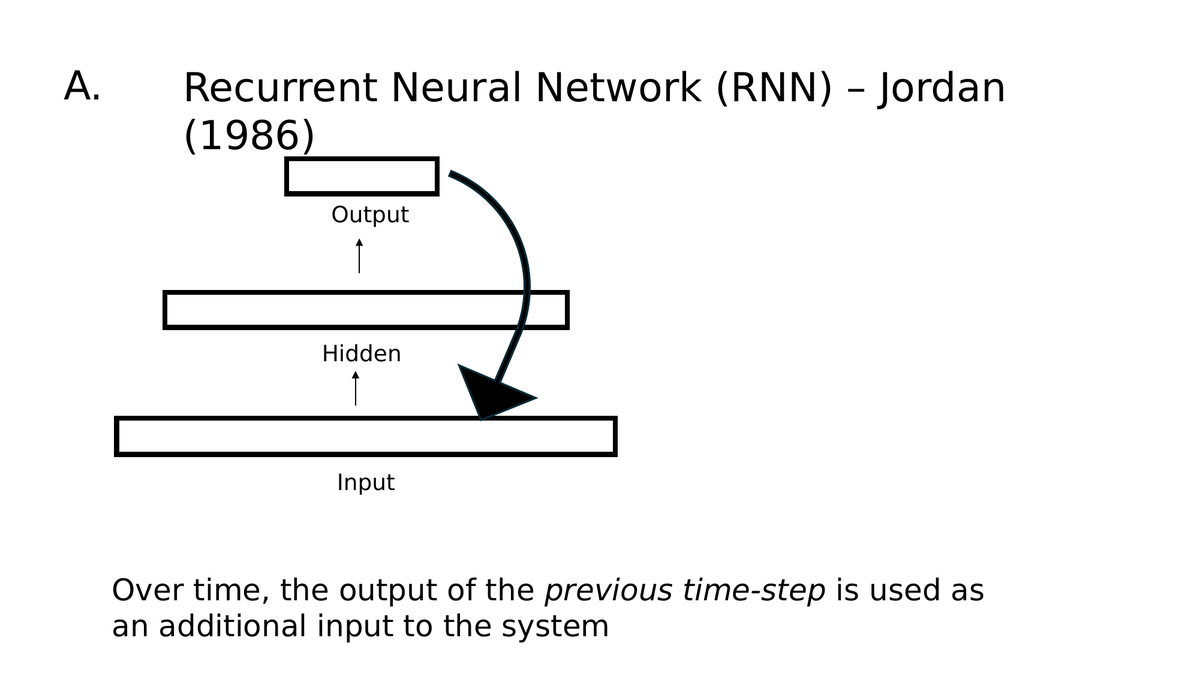

*Jordan (1986) — the output at each time step is fed back as an extra input on the next step.*

**Elman (1990) — the Simple Recurrent Network (SRN)** made a subtle but crucial change: instead of feeding back the *output*, feed back the *hidden state*. The hidden state is richer than the output — it contains the network's full internal representation, not just its decision.

Elman stored the previous hidden state in a separate **"context" layer**, which then feeds into the hidden layer on the next time step along with the new input. The weights from context → hidden are learned, so the network can discover which aspects of its recent past are worth carrying forward.

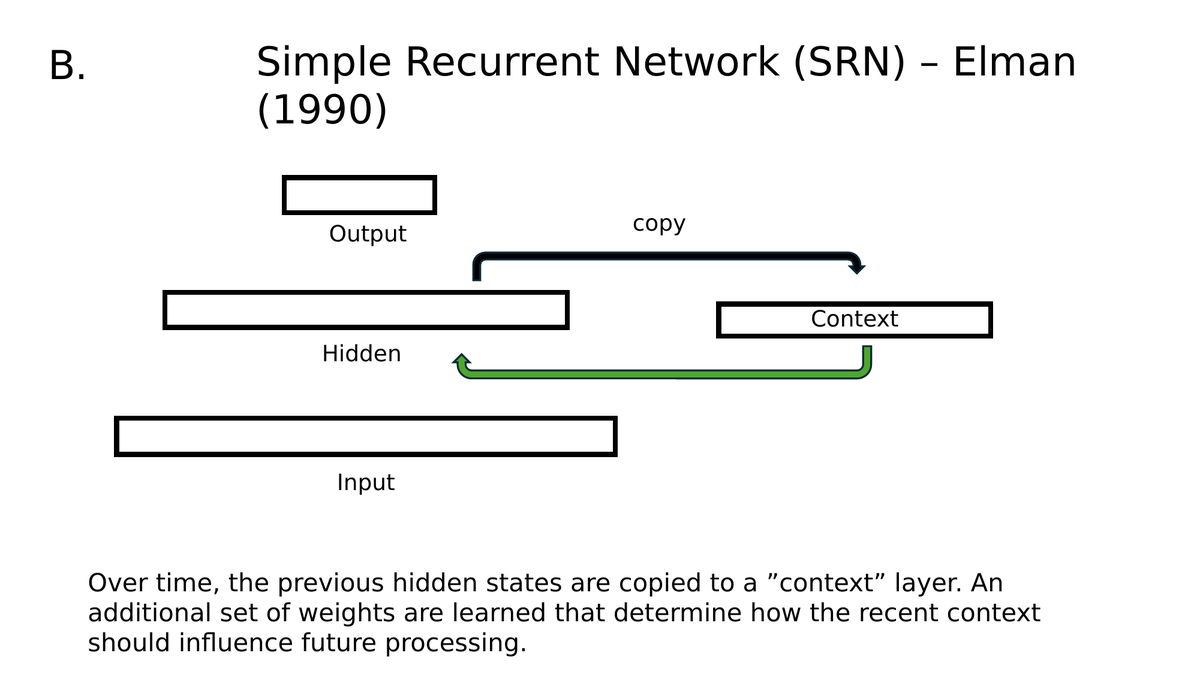

*Elman's Simple Recurrent Network. The previous hidden state is copied into a 'context' layer and combined with the new input.*

Here' we consider "Elman nets" or "SRNs" and just call them "recurrent neural networks" or "RNN's"

### How RNNs Work

An RNN processes inputs one at a time, but at each step, it combines:
1. The current input (e.g., the current word)
2. A **context-dependent hidden state* — its memory of everything it has processed so far

After each step, it updates the hidden state. This is the simplest mathematical formulation:

$$h_t = f(W_{xh} x_t + W_{hh} h_{t-1} + b)$$

Where:
- $x_t$ is the input at time $t$ (e.g., the embedding of a word)
- $h_{t-1}$ is the hidden state from the previous time step
- $h_t$ is the updated hidden state — the network's current "memory"
- $W_{xh}$ and $W_{hh}$ are learned weight matrices (from input to hidden, and context to hidden, respectively)
- $f$ is a nonlinear activation (tanh or ReLU)

The key idea: **$h_t$ is a compressed summary of the entire sequence seen so far**. When the RNN processes "bats" in the baseball sentence, its hidden state already contains information about "Dodgers" and "dugout" — which shapes how "bats" gets represented.

See the diagram below (standard unrolled RNN illustration):


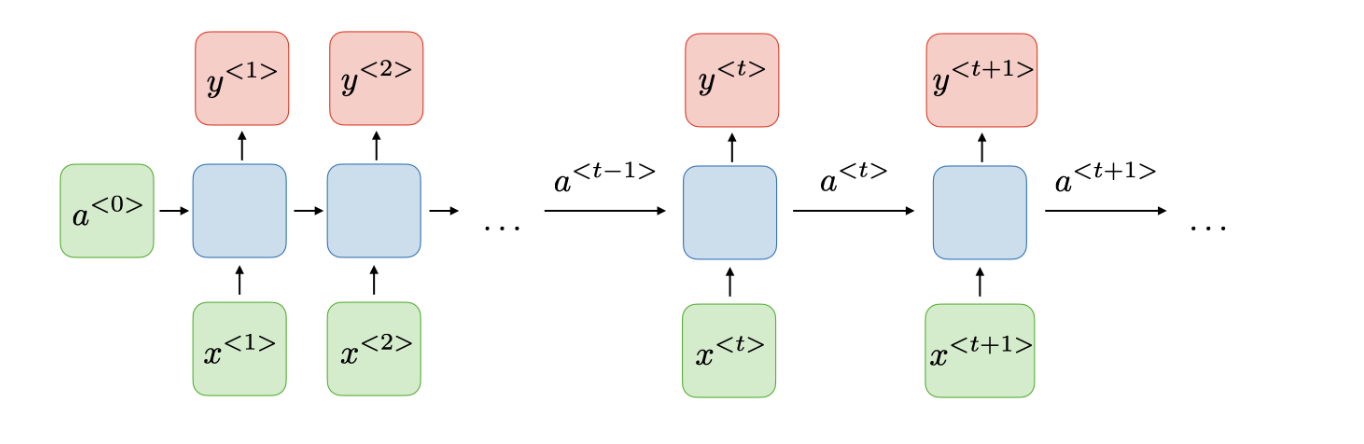

### Discussion Question

> The hidden state $h_t$ is a *compressed* summary — a fixed-size vector, no matter how long the sequence has been. What does this predict about an RNN's ability to remember information from very long ago? Can you think of analogies to human working memory and its limitations (e.g., the famous "7 ± 2" chunks)? What if the dimensionality of the vector space is made larger?


### A Toy Demonstration: Learning Sequential Structure

To see the mechanics clearly, we'll train a simple RNN on a very predictable task: given the current integer, predict the next one.

$$1 \to 2,\quad 2 \to 3,\quad 3 \to 4,\quad \ldots$$

A feedforward network could in principle learn this as a lookup table. But  with an RNN, the sequential structure is built right in.


In [ ]:
import torch
from torch import nn, optim
import torch.nn.functional as F

### Creating Embeddings for Integers

In the "catastrophic forgetting" example above, we provide unique random binary codes that correspond to each number. Here, we'll let the RNN **learn** a representation for each integer. This is called an **embedding** — each integer is mapped to a vector in some learned high-dimensional space. Similar integers (like 4 and 5) may end up with similar embeddings as a result of training.

This idea — learning a dense vector per discrete symbol — is central to modern language models, where each word gets an embedding.


In [ ]:
vocab_size = 50        # how high we are counting
embedding_size = 10    # dimensionality of the representational space

integer_sequence = list(range(0, vocab_size))
x = integer_sequence[:-1]  # inputs: 0, 1, 2, ..., 48
y = integer_sequence[1:]   # outputs: 1, 2, 3, ..., 49

# Components of our model
embedding = nn.Embedding(vocab_size, embedding_size)   # integer → vector
rnn = nn.RNN(embedding_size, embedding_size, batch_first=True)  # vector, hidden → hidden
e2v = nn.Linear(embedding_size, vocab_size)  # hidden → vocab-sized output

print(f'Inputs : {x}')
print(f'Targets: {y}')


In [ ]:
batch_size = 1
seq_len = len(y)
inputs_t = torch.tensor([x])

opt = optim.SGD(lr=0.02, params=list(embedding.parameters())
                                 + list(rnn.parameters())
                                 + list(e2v.parameters()))


In [ ]:
num_epochs = 10000
losses = []

for epoch in range(num_epochs):

    # --- STEP 1: EMBEDDING ---
    # Convert each integer in the input sequence to a learned vector.
    # inputs_t has shape (1, 49) — one sequence of 49 integers.
    # After embedding: x_ has shape (1, 49, 10) — each integer is now
    # a 10-dimensional vector. The network will learn what these vectors
    # should be during training.
    x_ = embedding(inputs_t)

    # --- STEP 2: RNN FORWARD PASS ---
    # This is where the recurrence happens. The RNN processes the sequence
    # one step at a time, maintaining a hidden state that carries information
    # forward from earlier positions.
    #
    # emb_out: shape (1, 49, 10) — the hidden state at EVERY time step.
    #          This is what we use to make predictions at each position.
    # h_n:     shape (1, 1, 10) — the hidden state at the LAST time step only.
    #          Think of this as the RNN's "summary" of the entire sequence.
    #          (We don't use h_n here, but it's useful for other tasks.)
    emb_out, h_n = rnn(x_)

    # --- STEP 3: PREDICT NEXT INTEGER ---
    # At each time step, map the hidden state to a score for every possible
    # integer in the vocabulary. The integer with the highest score is the
    # network's prediction for "what comes next."
    # outputs: shape (1, 49, 50) — at each of 49 positions, a score for
    #          each of the 50 possible integers.
    outputs = e2v(emb_out)

    # --- STEP 4: COMPUTE LOSS ---
    # Reshape for cross-entropy: it expects (num_predictions, num_classes)
    # for the outputs, and a flat list of correct answers for the targets.
    # We flatten across batch and time: 1 batch × 49 steps = 49 predictions.
    outputs_flat = outputs.view(batch_size * seq_len, vocab_size)
    y_flat = torch.tensor([y]).view(batch_size * seq_len)

    # Cross-entropy loss measures: did the network put high probability
    # on the correct next integer at each step?
    # It's the standard loss for "pick one from many categories" tasks.
    loss = F.cross_entropy(outputs_flat, y_flat)
    losses.append(loss.item())

    # --- STEP 5: UPDATE WEIGHTS ---
    opt.zero_grad()    # Clear old gradients
    loss.backward()    # Compute gradients (this is backpropagation through time!)
    opt.step()         # Nudge all weights (embedding, RNN, and output layer)

    # Print progress every 1000 epochs
    if epoch % 1000 == 0:
        # .max(dim=-1) returns (values, indices) along the last dimension.
        # The indices ARE the predicted integers (whichever scored highest).
        _, preds = outputs.max(dim=-1)
        print(f'epoch {epoch:5d} | loss {loss:.4f} | preds[:10] {preds[0, :10].tolist()}')

# Final check: does the network predict the correct successor for every integer?
_, preds = outputs.max(dim=-1)
print(f'\nFinal predictions: {preds[0].tolist()}')
print(f'Targets          : {y}')

In [ ]:
# Plot the learning curve
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('RNN learning the integer successor function')
plt.yscale('log')
plt.show()


### A Cleaner Demonstration: Context That Persists Over Time

The successor task is nice, but doesn't really *force* the RNN to use context — you could almost guess the next integer from the current one alone. We need a task where context *actually matters* over time.

Here's a more revealing setup: imagine the network is reading a stream of tokens organized into **blocks**, where each block comes from a different "topic." A token's meaning depends on which topic is currently active. To predict the next token well, the network has to **track the current topic across multiple time steps**.



Some real-world situations with this structure:

<b> Listening to a conversation at a party. </b> The same word — "shot" — means something completely different when the topic is basketball versus photography versus what's to drink. If you zone out and miss the topic shift, you'll be confused. Your brain tracks the current conversational topic and uses it to interpret each new word.

<b> Reading a news feed. </b> Your phone shows a stream of headlines: "Eagles crush Giants in fourth quarter" → "Eagles soar to 12-2" → "Market rallies on strong jobs report" → "Rally draws thousands downtown." At the sports/finance boundary, the word "rally" flips meaning. You track the current section to make sense of each headline.

<b> A child learning that context changes the rules. </b> At home, running and yelling is fine. At school, the same behaviors get you in trouble. The actions (tokens) are the same; the context (topic) determines what happens next. The child has to learn to track "where am I right now?" to predict consequences.

Our task is a simplified version of this:

The vocabulary is 10 tokens (0–9).
Each sequence consists of alternating blocks of ~5 tokens, each drawn from one of two topic distributions.

<b> Topic A </b>: tokens biased toward 0–4
<b> Topic B </b>: tokens biased toward 5–9
Middle tokens (3–6) appear in both topics, so individual tokens don't always reveal the topic — just like "shot" or "rally" don't reveal their meaning without context.


The network's task is to predict the next token.


Because topics persist over several time steps, a good RNN should develop hidden states that are **stable within a block** and **shift when the topic changes** — giving us clear block structure to examine with Representational Similarity Analysis.



In [ ]:
# Build a context-tracking dataset
# Each sequence is a series of blocks, each block drawn from one of two topic distributions.

def make_context_data(n_sequences=500, n_blocks=6, block_len=5, vocab_size=10, seed=0):
    """
    Returns:
      X     : LongTensor (n_sequences, seq_len)  — input tokens
      Y     : LongTensor (n_sequences, seq_len)  — target next tokens
      topics: LongTensor (n_sequences, seq_len)  — which topic was active at each step
                                                   (useful for RSA but not given to the network)
    """
    rng = np.random.default_rng(seed)
    seq_len = n_blocks * block_len

    # Two topic distributions over the 10-token vocabulary.
    # Topic A favors 0-4; Topic B favors 5-9; the middle tokens 3-6 appear in both.
    topic_A_dist = np.array([0.22, 0.22, 0.22, 0.15, 0.10, 0.05, 0.02, 0.01, 0.005, 0.005])
    topic_B_dist = np.array([0.005, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.22, 0.22, 0.22])
    topic_A_dist /= topic_A_dist.sum()
    topic_B_dist /= topic_B_dist.sum()
    dists = [topic_A_dist, topic_B_dist]

    X = np.zeros((n_sequences, seq_len), dtype=int)
    topics = np.zeros((n_sequences, seq_len), dtype=int)

    for s in range(n_sequences):
        start_topic = rng.integers(2)      # random starting topic for variety
        for b in range(n_blocks):
            topic = (start_topic + b) % 2  # topics alternate through the sequence
            block_tokens = rng.choice(vocab_size, size=block_len, p=dists[topic])
            X[s, b*block_len:(b+1)*block_len] = block_tokens
            topics[s, b*block_len:(b+1)*block_len] = topic

    # Target at step t is the token at step t+1 (rolled); last step uses itself as padding.
    Y = np.concatenate([X[:, 1:], X[:, -1:].copy()], axis=1)
    return torch.LongTensor(X), torch.LongTensor(Y), torch.LongTensor(topics)

X, Y, topics = make_context_data()

# Show what a sequence looks like
print('Example sequence:')
print(f'  tokens : {X[0].tolist()}')
print(f'  topics : {topics[0].tolist()}  (0 = Topic A, 1 = Topic B)')
print(f'  targets: {Y[0].tolist()}')
print()
print(f'Shape: {X.shape} sequences × time steps')


In [ ]:
# Define the RNN for the context-tracking task
class ContextRNN(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=16, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        e = self.embedding(x)
        h_seq, _ = self.rnn(e)
        return self.out(h_seq), h_seq  # also return hidden states for analysis

ctx_model = ContextRNN()
opt = optim.Adam(ctx_model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

losses = []
for epoch in range(400):
    opt.zero_grad()
    logits, _ = ctx_model(X)
    loss = criterion(logits.reshape(-1, 10), Y.reshape(-1))
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f'epoch {epoch:4d} | loss {loss.item():.4f}')

# Compare with a baseline: predicting the marginal token distribution ignores context.
# A context-aware model should beat the marginal.
marginal_dist = np.bincount(X.numpy().flatten(), minlength=10) / X.numel()
marginal_entropy = -np.sum(marginal_dist * np.log(marginal_dist + 1e-12))
print(f'\nFinal loss: {losses[-1]:.4f}')
print(f'Marginal-predictor baseline (no context): {marginal_entropy:.4f}')
print('If loss < baseline, the network is using context.')


In [ ]:
# Visualize a single test sequence and the RNN's hidden state trajectory
# Watch how the hidden state shifts across topic boundaries.

with torch.no_grad():
    test_X = X[0:1]
    test_topics = topics[0].numpy()
    _, h_seq = ctx_model(test_X)
    hidden_states = h_seq[0].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6),
                          gridspec_kw={'height_ratios': [3, 0.5, 0.5]})

# Top: hidden state over time
im = axes[0].imshow(hidden_states.T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(test_X[0])))
axes[0].set_xticklabels(test_X[0].tolist())
axes[0].set_ylabel('Hidden unit')
axes[0].set_title('RNN hidden state across the sequence\n(each column = one time step; color = activation)')
plt.colorbar(im, ax=axes[0], fraction=0.015)

# Middle: topic strip
axes[1].imshow(test_topics.reshape(1, -1), cmap='coolwarm', aspect='auto', vmin=0, vmax=1)
axes[1].set_yticks([0]); axes[1].set_yticklabels(['Topic'])
axes[1].set_xticks(range(len(test_topics)))
axes[1].set_xticklabels(['A' if t == 0 else 'B' for t in test_topics], fontsize=8)

# Bottom: tokens
axes[2].axis('off')
axes[2].text(0.5, 0.5, 'Input tokens: ' + '  '.join(str(t) for t in test_X[0].tolist()),
             ha='center', va='center', fontsize=10, family='monospace',
             transform=axes[2].transAxes)

plt.tight_layout()
plt.show()


### How Does the RNN's Representation Change Over Time?

Because the task has **slow-changing structure** (topics persist across blocks), the hidden state should also change slowly — drifting gradually within a block, then shifting at topic boundaries.

In Week 2 we used **Representational Similarity Analysis (RSA)** to compare representations across systems. Here, we use it to ask a *within-system* question: **does the hidden state at time $t$ look more like the hidden state at nearby times, or at distant times?** And does it cluster by *topic*?

We'll build a representational dissimilarity matrix (RDM) over time steps and see if its structure matches the topic-block structure of the sequence.


In [ ]:
# Build an RDM over time steps, then a "topic match" matrix for comparison.
from scipy.spatial.distance import pdist, squareform

# Use the same test sequence as above
seq_len = hidden_states.shape[0]
rdm_hidden = squareform(pdist(hidden_states, metric='cosine'))

# Build a "topic match" RDM — 0 if same topic, 1 if different topic
topic_rdm = (test_topics[:, None] != test_topics[None, :]).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: RNN representational dissimilarity
im0 = axes[0].imshow(rdm_hidden, cmap='viridis')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Time step')
axes[0].set_title('RNN Representational Dissimilarity\n(cosine distance between hidden states)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Right: topic-match structure (what we'd hope the RNN reflects)
im1 = axes[1].imshow(topic_rdm, cmap='viridis')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Time step')
axes[1].set_title('Topic Structure\n(dark = same topic, light = different)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Add tick labels showing topic per step
tick_labels = ['A' if t == 0 else 'B' for t in test_topics]
for ax in axes:
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(tick_labels, fontsize=7)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(tick_labels, fontsize=7)

plt.tight_layout()
plt.show()


### Interpreting the Dissimilarity Matrix

If the RNN has learned to track topic, the left panel should mirror the block structure of the right panel:

- **Dark blocks along the diagonal** (of size equal to a topic block) — hidden states at nearby time steps *within a block* are similar, because the topic isn't changing.
- **Brighter off-diagonal squares** — hidden states at time steps in *different topic blocks* are more dissimilar.
- **Checkerboard pattern** — if topics A-B-A-B alternate, you'll see a pattern where all A blocks are similar to each other and all B blocks are similar to each other, with A and B blocks differing.



### Does This Structure Emerge *During* Training?

We've shown the final trained network encodes topic in its representational geometry. But was this always true? Or did it *emerge* as training progressed? Let's retrain from scratch while recording how the representational geometry evolves across epochs.

In [ ]:
# Quantify: does the RNN's representational geometry actually reflect topic structure?
# Correlate the neural RDM with the topic RDM (upper triangle only).
from scipy.stats import pearsonr

triu_idx = np.triu_indices_from(rdm_hidden, k=1)
r, p = pearsonr(rdm_hidden[triu_idx], topic_rdm[triu_idx])

print(f'Correlation between RNN representational geometry and topic structure:')
print(f'  r = {r:.4f},  p = {p:.4g}')
print()
print('A positive r means: time steps in the same topic have more similar hidden states')
print('than time steps in different topics. The network has organized its internal')
print('representations around the latent topic variable, even though topic was never')
print('provided as input.')


In [ ]:
# Retrain from scratch, snapshotting the RDM at various epochs.
ctx_model2 = ContextRNN()
opt2 = optim.Adam(ctx_model2.parameters(), lr=0.005)

# Fixed test sequence so snapshots are directly comparable
snap_X = X[0:1]
snap_topics = topics[0].numpy()
snap_topic_rdm = (snap_topics[:, None] != snap_topics[None, :]).astype(float)
triu_snap = np.triu_indices_from(snap_topic_rdm, k=1)

snapshot_epochs = [0, 5, 20, 50, 150, 400]
snapshots = {}
rsa_scores = []

for epoch in range(401):
    opt2.zero_grad()
    logits, _ = ctx_model2(X)
    loss = criterion(logits.reshape(-1, 10), Y.reshape(-1))
    loss.backward()
    opt2.step()

    with torch.no_grad():
        _, h_seq = ctx_model2(snap_X)
        hs = h_seq[0].numpy()
        rdm_now = squareform(pdist(hs, metric='cosine'))
        r_now, _ = pearsonr(rdm_now[triu_snap], snap_topic_rdm[triu_snap])
        rsa_scores.append(r_now)

    if epoch in snapshot_epochs:
        snapshots[epoch] = rdm_now

# Plot snapshots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, ep in zip(axes.flat, snapshot_epochs):
    im = ax.imshow(snapshots[ep], cmap='viridis')
    r_at_ep, _ = pearsonr(snapshots[ep][triu_snap], snap_topic_rdm[triu_snap])
    ax.set_title(f'Epoch {ep}\nRSA with topic: r = {r_at_ep:.3f}')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Representational Geometry Emerging Over Training\n'
             '(RDMs at increasing epochs — block structure appears as the task is solved)',
             fontsize=12)
plt.tight_layout()
plt.show()


In last week's lab, we cared about the second-order correlations between conv net similarity and human similarity judgment. We might also be interested in how well network (or human) similarity relates to a hypothetical "optimal" similarity model, such as in the "topic structure" model above.

In [ ]:
# Plot RSA-with-topic across all training epochs
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rsa_scores)
ax.set_xlabel('Training Epoch')
ax.set_ylabel('RSA: r(hidden state RDM, topic RDM)')
ax.set_title('Topic-Encoding in Hidden States Emerges During Training')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Discussion Question: Representation Emerging in Time

> What you just watched is pretty remarkable!: a feature of the *world* (the "topic") becoming progressively inscribed in the *geometry* of the network's internal representations, simply through gradient descent on a behavioral task.
>
> **A.** This is a small-scale version of a phenomenon that has been claimed about large language models: that they develop internal representations of abstract concepts (syntax trees, physical properties, mental states of characters) just from being trained on next-word prediction. But what evidence would we want to see to distinguish "genuinely representing X" from "coincidentally correlated with X"?
>
> **B.** We've now seen representational geometry at three timescales:
> - Across *layers* of a trained network (Week 2 — AlexNet's depth hierarchy)
> - Across *time* within a single forward pass (this week — the RNN's hidden state evolving across a sequence)
> - Across *epochs* of training (just now — representations emerging as the network learns)
>
> These are three fundamentally different kinds of "change." What does each tell us about the network? Which, if any, has a natural parallel in human cognition?


.

### Discussion Question (Synthesis)

> Let's tie everything together:
>
> **A.** Part A (rational analysis) said: memory should be sensitive to *frequency* of experience. Part C (RNNs) introduces memory that is sensitive to *recent context*. Are these the same kind of memory? Could a single system handle both?
>
> **B.** Part B (catastrophic forgetting) showed that weight-based memory can be fragile. The RNN in Part C *also* uses weights for its long-term knowledge, but its hidden state holds short-term knowledge separately. Is this enough to overcome catastrophic forgetting?
>
> **C.** If you had to diagnose what's *still missing* from these models — relative to human memory — what would you name as the biggest gap?


### Looking Ahead

Modern language models (GPT, Claude, etc.) use a related but more sophisticated mechanism called **attention** (in Transformers) rather than recurrent hidden states. Attention lets the network directly look back at any previous position in the sequence, rather than relying on everything being compressed into a single vector.

What stays the same, though, is the core insight from this lab: *processing any input intelligently requires context, and context requires memory*.

